## 1. Install and Import Libraries

In [4]:
# pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Create the Dataset

In [5]:
data = {
    "Order_ID": range(101, 121),

    # Create 20 consecutive dates
    "Date": pd.date_range(
        start="2025-01-01",
        periods=20,
        freq="D"
    ),

    "City": [
        "Delhi", "Mumbai", "Indore", "Pune", "Delhi",
        "Mumbai", "Indore", "Pune", "Delhi", "Mumbai",
        "Indore", "Pune", "Delhi", "Mumbai", "Indore",
        "Pune", "Delhi", "Mumbai", "Indore", "Pune"
    ],

    "Category": [
        "Electronics", "Furniture", "Clothing", "Electronics",
        "Clothing", "Furniture", "Electronics", "Clothing",
        "Furniture", "Electronics", "Clothing", "Furniture",
        "Electronics", "Clothing", "Furniture", "Electronics",
        "Clothing", "Furniture", "Electronics", "Clothing"
    ],

    "Product": [
        "Laptop", "Chair", "T-Shirt", "Mobile", "Jeans",
        "Table", "Headphones", "Shoes", "Sofa", "Laptop",
        "T-Shirt", "Chair", "Mobile", "Jeans", "Table",
        "Headphones", "Shoes", "Sofa", "Laptop", "T-Shirt"
    ],

    "Sales": [
        75000, 18000, 2500, 45000, 3200,
        22000, 5000, 4500, 35000, 82000,
        2800, 16000, 52000, 3500, 24000,
        6500, 4800, 38000, 79000, 3000
    ],

    "Quantity": [
        2, 3, 5, 2, 4,
        3, 6, 5, 2, 3,
        7, 4, 2, 6, 3,
        5, 8, 4, 2, 6
    ],

    "Profit": [
        12000, 3500, 700, 8000, 900,
        4500, 1200, 1100, 6000, 15000,
        750, 3200, 9500, 850, 5000,
        1500, 1000, 6500, 13000, 800
    ]
}

# Convert the dictionary into a Pandas DataFrame
df = pd.DataFrame(data)

# Display the first five rows
df.head()

,Order_ID,Date,City,Category,Product,Sales,Quantity,Profit
0,101,2025-01-01,Delhi,Electronics,Laptop,75000,2,12000
1,102,2025-01-02,Mumbai,Furniture,Chair,18000,3,3500
2,103,2025-01-03,Indore,Clothing,T-Shirt,2500,5,700
3,104,2025-01-04,Pune,Electronics,Mobile,45000,2,8000
4,105,2025-01-05,Delhi,Clothing,Jeans,3200,4,900


## 3. Understand the Dataset

In [6]:
print("Shape of dataset:", df.shape)
df.info()

print(df.describe())


print("\nNumber of orders in each category:")
print(df["Category"].value_counts())

print("\nNumber of orders in each city:")
print(df["City"].value_counts())


Shape of dataset: (20, 8)
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order_ID  20 non-null     int64         
 1   Date      20 non-null     datetime64[us]
 2   City      20 non-null     str           
 3   Category  20 non-null     str           
 4   Product   20 non-null     str           
 5   Sales     20 non-null     int64         
 6   Quantity  20 non-null     int64         
 7   Profit    20 non-null     int64         
dtypes: datetime64[us](1), int64(4), str(3)
memory usage: 1.4 KB
        Order_ID                 Date         Sales   Quantity        Profit
count   20.00000                   20     20.000000  20.000000     20.000000
mean   110.50000  2025-01-10 12:00:00  26090.000000   4.100000   4750.000000
min    101.00000  2025-01-01 00:00:00   2500.000000   2.000000    700.000000
25%    105.75000  2025-01-05 18:00:00   4250.00000

# Part 1 — Matplotlib

## 4. Basic Line Plot
A line plot is useful for showing **trends over time**.

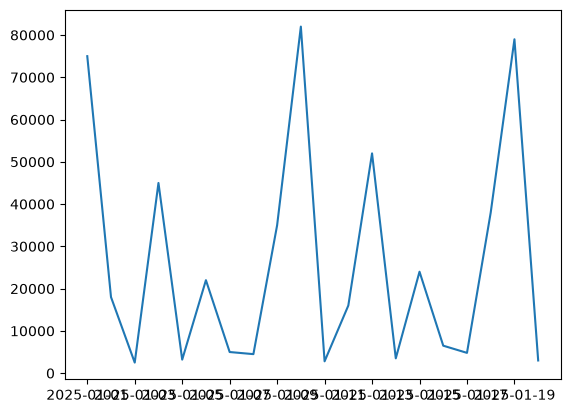

In [7]:
# Plot Date on the X-axis and Sales on the Y-axis
plt.plot(df["Date"], df["Sales"])

# Display the graph
plt.show()

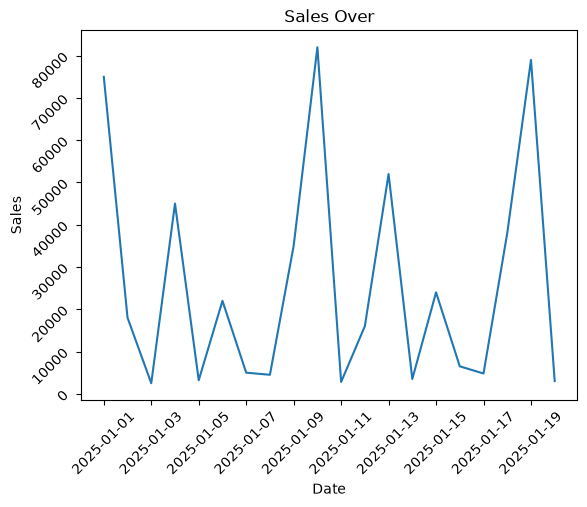

In [8]:
#Add a title and axis labels

plt.plot(df["Date"], df["Sales"])

plt.title("Sales Over")
plt.xlabel("Date")
plt.ylabel("Sales")

# Dates can overlap, so rotate them by 45 degrees
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

## 6. Multiple Lines — Sales vs Profit

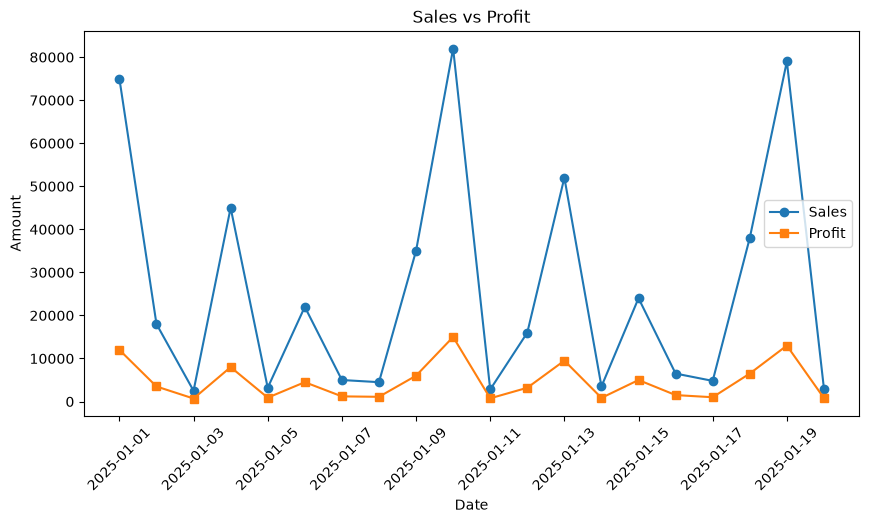

In [9]:
plt.figure(figsize=(10, 5))

# First line: Sales
plt.plot(
    df["Date"],
    df["Sales"],
    marker="o", # Put a circle at each data point
    label="Sales"
)

# Second line: Profit
plt.plot(
    df["Date"],
    df["Profit"],
    marker="s",# Put a square at each data point
    label="Profit"
)

plt.title("Sales vs Profit")
plt.xlabel("Date")
plt.ylabel("Amount")

plt.xticks(rotation=45)

# legend() displays the labels defined above
plt.legend()

plt.show()

## 7. Bar Chart — Sales by Category

Category
Clothing        24300
Electronics    344500
Furniture      153000
Name: Sales, dtype: int64


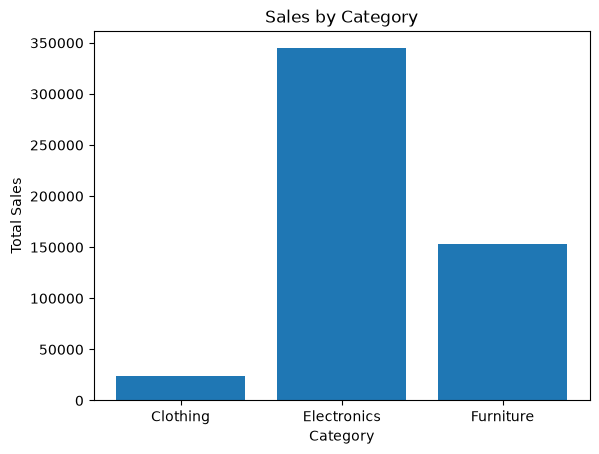

In [10]:

# groupby() groups rows according to Category.
# sum() calculates total sales for each category.

category_sales = df.groupby("Category")["Sales"].sum()

print(category_sales)

# Draw a vertical bar chart
plt.bar(
    category_sales.index,   #x,y
    category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

## 8. Horizontal Bar Chart

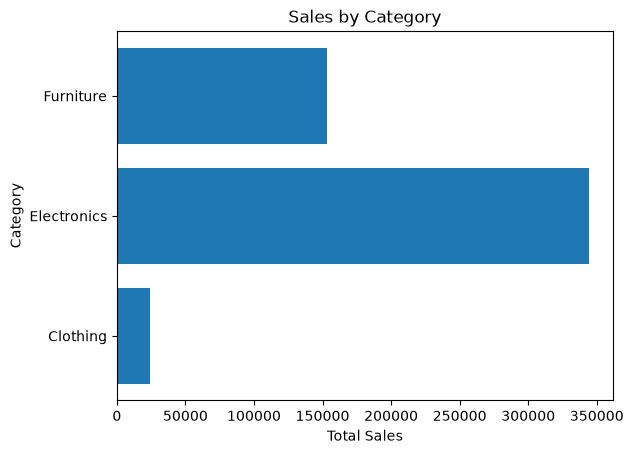

In [11]:
# barh() creates a horizontal bar chart.
# Horizontal bars can be useful when category names are long.

plt.barh(
    category_sales.index,
    category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.show()

## 10. Pie Chart

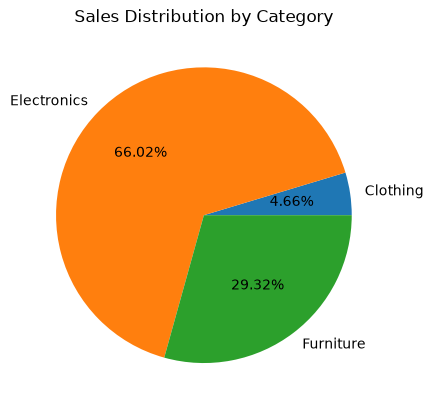

In [12]:
# A pie chart is useful for showing proportions or percentages.

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.2f%%"  # Show percentage with one decimal place
)

plt.title("Sales Distribution by Category")
plt.show()

## 11. Histogram — Distribution of Sales

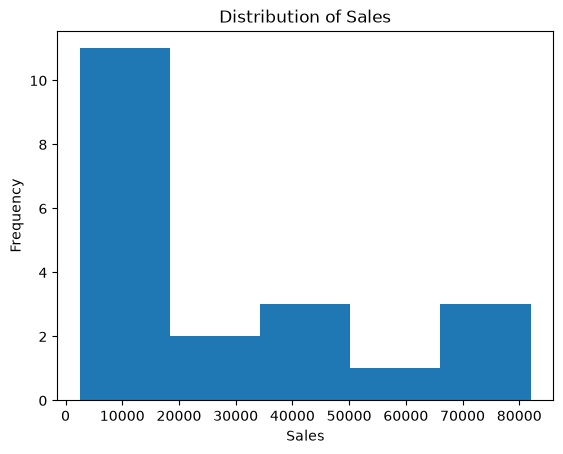

In [13]:
# A histogram shows the distribution of numerical values.
# bins=5 divides the Sales values into five intervals.

plt.hist(
    df["Sales"],
    bins=5,
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

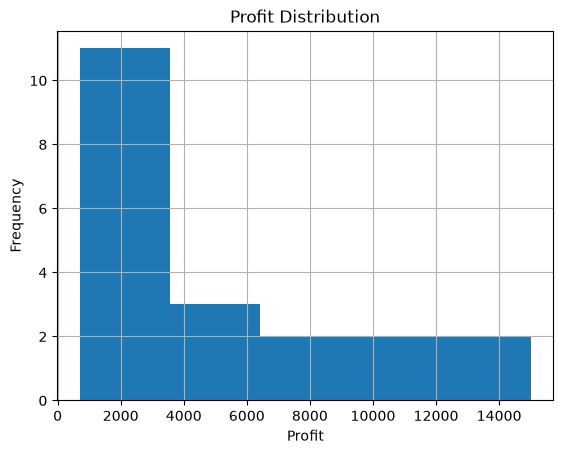

In [14]:
# We can also study the distribution of Profit.

plt.hist(
    df["Profit"],
    bins=5
)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.grid()

plt.show()

## 12. Scatter Plot — Sales vs Profit

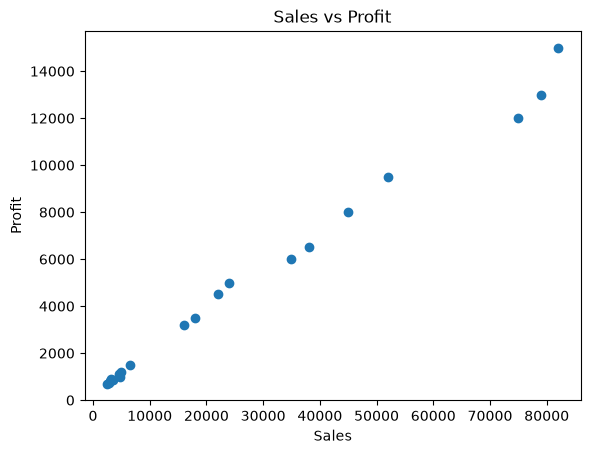

In [15]:
# A scatter plot shows the relationship between two numerical variables.

plt.scatter(
    df["Sales"],
    df["Profit"]
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

# Part 2 — Seaborn

## 14. Seaborn Line Plot

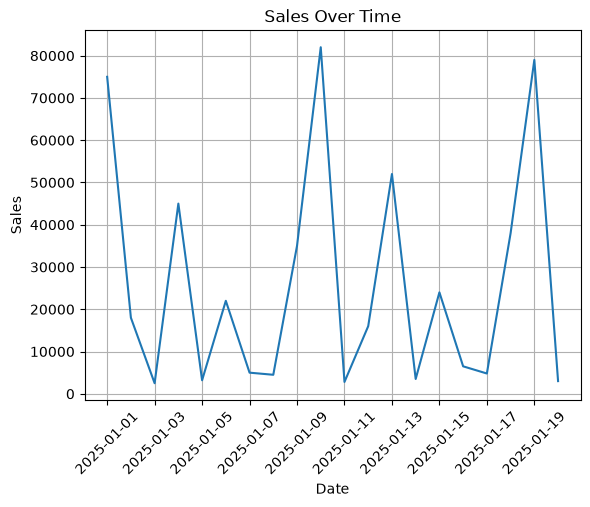

In [16]:
# Seaborn works directly with DataFrames.
# data=df tells Seaborn which DataFrame to use.

sns.lineplot(
    data=df,
    x="Date",
    y="Sales"
)

plt.title("Sales Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.show()

## 15. Seaborn Bar Plot

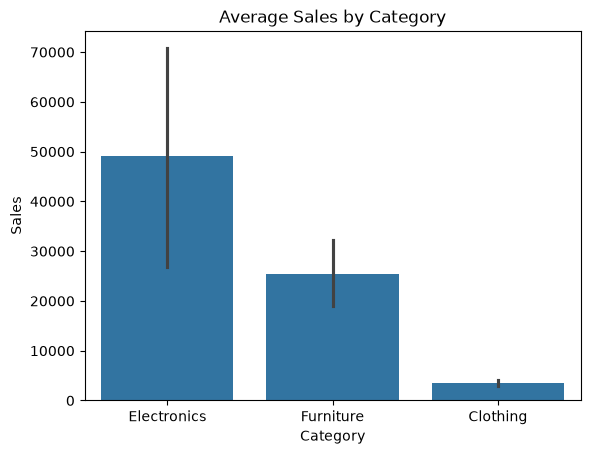

In [17]:
# barplot() creates a statistical bar chart.
# By default, when several rows have the same category,
# Seaborn calculates the mean of the numerical variable.

sns.barplot(
    data=df,
    x="Category",
    y="Sales"
)

plt.title("Average Sales by Category")

plt.show()

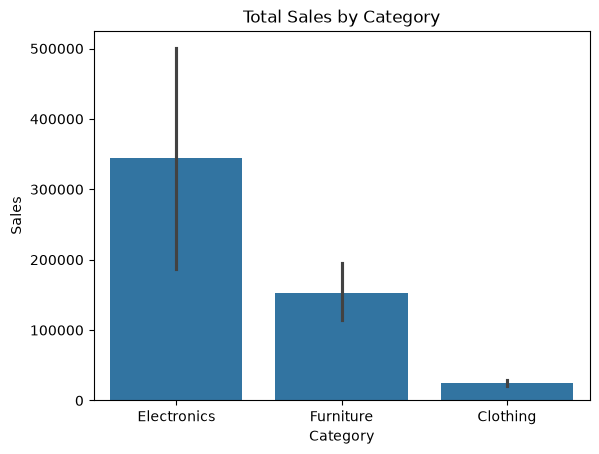

In [18]:
# We can explicitly calculate TOTAL sales instead of the default mean.
# estimator="sum" tells Seaborn to add the sales values.

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator="sum"
)
plt.title("Total Sales by Category")
plt.show()


## 16. Count Plot

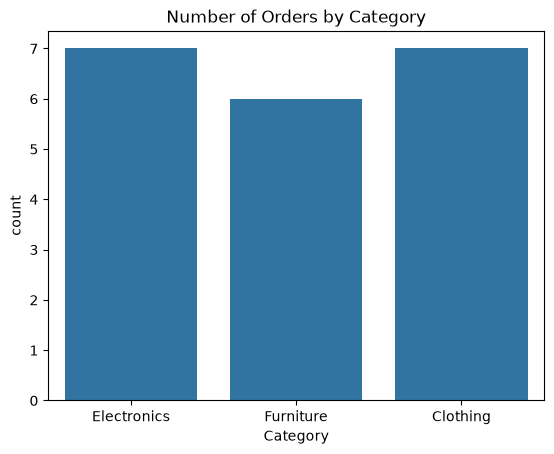

In [19]:
# countplot() counts the number of observations in each category.

sns.countplot(
    data=df,
    x="Category"
)

plt.title("Number of Orders by Category")
plt.show()

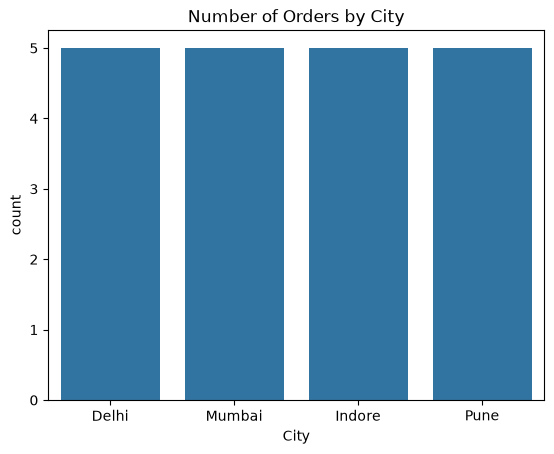

In [20]:
# We can also count orders city-wise.

sns.countplot(
    data=df,
    x="City"
)

plt.title("Number of Orders by City")

plt.show()

## 19. Seaborn Scatter Plot

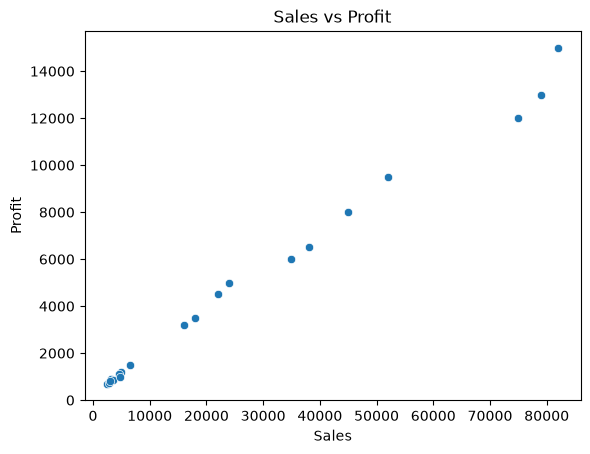

In [21]:
sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")
plt.show()

## 20. Scatter Plot with `hue`

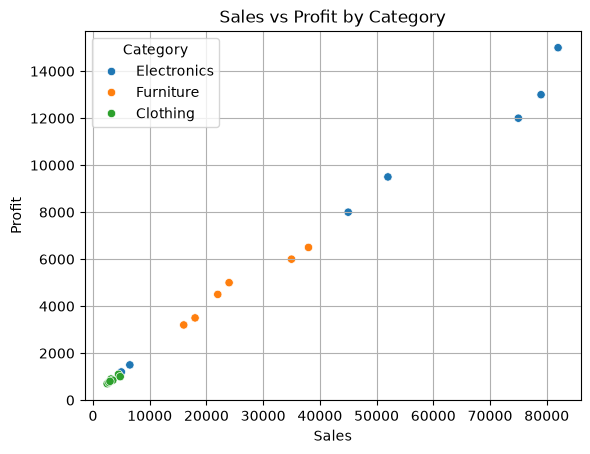

In [22]:
# hue creates different visual groups based on a categorical column.
# Here, each Category gets a different visual group.

sns.scatterplot(hue="Category",
    data=df,
    x="Sales",
    y="Profit",

)

plt.title("Sales vs Profit by Category")
plt.grid()
plt.show()

## 21. Scatter Plot with Hue and Size

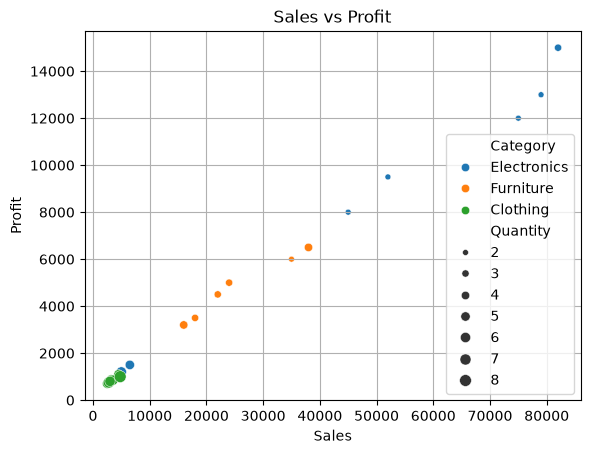

In [23]:
# Now we represent several variables in one chart:
# X-axis  -> Sales
# Y-axis  -> Profit
# Color   -> Category
# Size    -> Quantity

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category",
    size="Quantity"
)

plt.title("Sales vs Profit")
plt.grid()
plt.show()


In [24]:
data = {
"Sales": [
        75000, 18000, 2500, 45000, 3200,
        22000, 5000, 4500, 35000, 82000,
        2800, 16000, 52000, 3500, 24000,
        6500, 4800, 38000, 79000, 3000
    ],

    "Profit": [
        12000, 3500, 700, 8000, 900,
        4500, 1200, 1100, 6000, 15000,
        750, 3200, 9500, 850, 5000,
        1500, 1000, 6500, 13000, 800
    ]
}
#print(data)
for sales, profit in zip(data["Sales"], data["Profit"]):
    print("Sales:", sales, "Profit:", profit)

Sales: 75000 Profit: 12000
Sales: 18000 Profit: 3500
Sales: 2500 Profit: 700
Sales: 45000 Profit: 8000
Sales: 3200 Profit: 900
Sales: 22000 Profit: 4500
Sales: 5000 Profit: 1200
Sales: 4500 Profit: 1100
Sales: 35000 Profit: 6000
Sales: 82000 Profit: 15000
Sales: 2800 Profit: 750
Sales: 16000 Profit: 3200
Sales: 52000 Profit: 9500
Sales: 3500 Profit: 850
Sales: 24000 Profit: 5000
Sales: 6500 Profit: 1500
Sales: 4800 Profit: 1000
Sales: 38000 Profit: 6500
Sales: 79000 Profit: 13000
Sales: 3000 Profit: 800


In [25]:
print(df[["Sales", "Profit"]].corr())

           Sales    Profit
Sales   1.000000  0.996226
Profit  0.996226  1.000000


## 22. Regression Plot

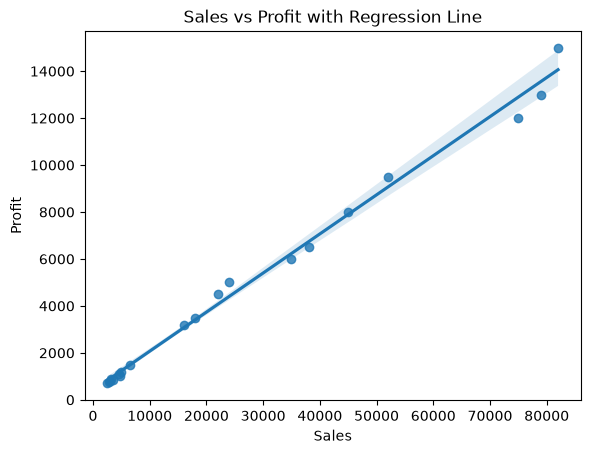

In [26]:
# regplot() adds a regression line to a scatter plot.
# This is useful for visually studying the relationship
# between two numerical variables.

sns.regplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit with Regression Line")

plt.show()

## 23. Correlation

In [27]:
# corr() calculates the correlation between numerical columns.
# Correlation values generally range from -1 to +1.

correlation = df[["Sales", "Quantity", "Profit"]].corr()

print(correlation)

             Sales  Quantity    Profit
Sales     1.000000 -0.742597  0.996226
Quantity -0.742597  1.000000 -0.750132
Profit    0.996226 -0.750132  1.000000


## 24. Correlation Heatmap

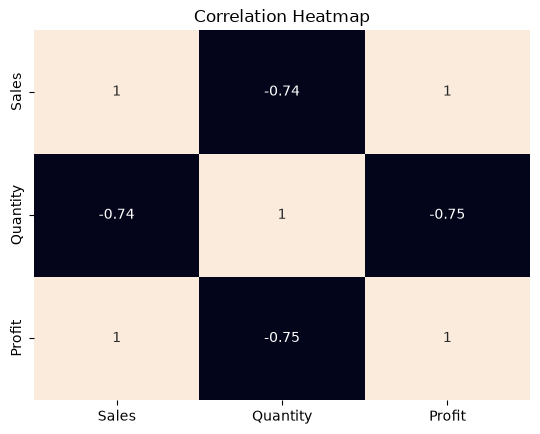

In [28]:
# A heatmap represents numerical values using different shades.
# annot=True writes the correlation value inside each cell.

sns.heatmap(
    correlation,
    annot=True,
    cbar=False
)

plt.title("Correlation Heatmap")
plt.show()

# Interpretation:
# +1  -> strong positive linear relationship
# -1  -> strong negative linear relationship
#  0  -> little or no linear relationship

## 26. Seaborn Theme

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

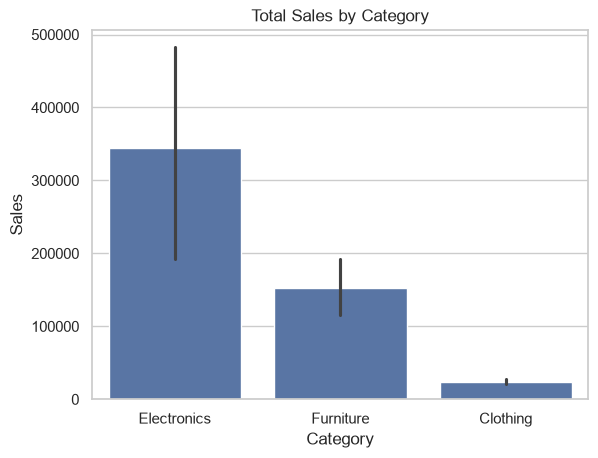

In [30]:
# Seaborn provides themes that can improve the appearance of charts.

sns.set_theme(style="whitegrid") # sns.set_theme(style="darkgrid")

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator="sum"
)

plt.title("Total Sales by Category")

plt.show()

Seaborn barplot() is using its default 95% confidence interval, the calculation is roughly based on the standard error of the mean.

Step 1: Calculate the mean

Suppose Electronics has these sales:

200

300

400

500

600

Mean:

$$ \bar{x} = \frac{200+300+400+500+600}{5}=400 $$

So the bar would be at 400.

Step 2: Calculate standard deviation

Standard deviation tells us how much the individual sales values vary around the mean.

For these values:

200 → difference from mean = -200

300 → -100

400 → 0

500 → +100

600 → +200

The standard deviation is approximately:

$$ SD = 141.42 $$

Step 3: Calculate standard error

The standard error (SE) tells us how uncertain our estimated mean is.

$$ SE = \frac{SD}{\sqrt{n}} $$

Here:

SD = 141.42

n = 5 observations

Therefore:

$$ SE = \frac{141.42}{\sqrt{5}} $$ $$ SE \approx 70.7 $$

Step 4: Calculate the confidence interval

For a 95% confidence interval, we use approximately:

$$ Mean \pm 1.96 \times SE $$

So:

$$ 400 \pm 1.96(70.7) $$ $$ 400 \pm 138.6 $$

Therefore:

261.4 to 538.6
	​
